In [1]:
from SpaLP.utils import prepare_inputs, set_seed,create_new_color_dict,Graph
from SpaLP.LP import SpatialLocalPooling
from SpaLP.utils import transfer_labels_by_cosine
import torch
import torch.nn as nn
import torch.optim as optim
import warnings
import scanpy as sc
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import anndata as ad
from tqdm import tqdm
import time

In [2]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [3]:
set_seed(7)

### pretraining on MERFISH mouse brain, Inference on unrelated mouse testis tissue and same mouse brain tissue

In [4]:
adata_batch1=sc.read_h5ad('/home/dbj/SpaLP/gittest/SpaLP/general/STARmapPLUS/MERFISH_-1.078.h5ad')
adata_batch1.var_names_make_unique()
adata_batch1.obs['batch']='MERFISH_mouse_brain'
adata_batch1.obs['type']='Pre-training data'



adata_batch2=sc.read_h5ad('/home/dbj/SpaLA/stereoseqmousegaowan/testis.h5ad')
adata_batch2.var_names_make_unique()
adata_batch2.obs['batch']='Mouse_testis'
adata_batch2.obs['type']='Inference data'

adata_batch3=sc.read_h5ad('/home/dbj/SpaLP/gittest/SpaLP/general/STARmapPLUS/MERFISH_-1.076.h5ad')
adata_batch3.var_names_make_unique()
adata_batch3.obs['batch']='MERFISH_mouse_brain'
adata_batch3.obs['type']='Inference data'

common_genes = adata_batch1.var_names.intersection(adata_batch2.var_names)
adata_batch1 = adata_batch1[:, common_genes].copy()
adata_batch2 = adata_batch2[:, common_genes].copy()
adata_batch3 = adata_batch3[:, common_genes].copy()

In [5]:
sc.pp.scale(adata_batch1)
adata_batch1.obsm['feat']=adata_batch1.X

In [6]:
k=9
graph = prepare_inputs(adata_batch1, k, device)

In [7]:
in_channels = graph.features.shape[1]
model = SpatialLocalPooling(in_channels, out_channels=64).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [8]:
epochs = 200
pbar = tqdm(range(epochs), desc="Training",ncols=200)
for epoch in pbar:
    start_time = time.time()
    model.train()
    optimizer.zero_grad()
    reconstructed,embedding = model(graph.features, graph.neighbor_idx)
    loss = criterion(reconstructed, graph.features)
    loss.backward()
    optimizer.step()
    elapsed = time.time() - start_time
    pbar.set_postfix({"Epoch": epoch,"Loss": f"{loss.item():.4f}"})

Training: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [00:04<00:00, 43.32it/s, Epoch=199, Loss=0.8614]


In [9]:
model.eval()
with torch.no_grad():
    reconstructed,embedding = model(graph.features, graph.neighbor_idx)
    reconstructed = reconstructed.cpu().numpy()
    embedding=embedding.cpu().numpy()

In [10]:
adata_batch1.obsm['SpaLP']=embedding

In [11]:
torch.save(model.state_dict(), "/home/dbj/SpaLP/gittest/SpaLP/general/MERFISH/unrelatedtissues/76_pretrian_model.pth")

In [12]:
adata_batch1.write_h5ad('/home/dbj/SpaLP/gittest/SpaLP/general/MERFISH/unrelatedtissues/Pre-training.h5ad',compression='gzip')

### zero-shot inference embedding

In [13]:
sc.pp.scale(adata_batch2)
adata_batch2.obsm['feat']=adata_batch2.X

sc.pp.scale(adata_batch3)
adata_batch3.obsm['feat']=adata_batch3.X

In [14]:
graph1 = prepare_inputs(adata_batch2, k=9, device=device)
graph2 = prepare_inputs(adata_batch3, k=9, device=device)

### zero-shot inference embedding on unrelated tissue

In [15]:
in_channels = graph1.features.shape[1]
model = SpatialLocalPooling(in_channels, out_channels=64).to(device)
model.load_state_dict(torch.load("/home/dbj/SpaLP/gittest/SpaLP/general/MERFISH/unrelatedtissues/76_pretrian_model.pth", map_location="cpu"))
model.eval()
with torch.no_grad():
    reconstructed,embedding = model(graph1.features, graph1.neighbor_idx)
    reconstructed = reconstructed.cpu().numpy()
    embedding=embedding.cpu().numpy()

adata_batch2.obsm['SpaLP']=embedding

### zero-shot inference embedding on same tissue

In [16]:
in_channels = graph2.features.shape[1]
model = SpatialLocalPooling(in_channels, out_channels=64).to(device)
model.load_state_dict(torch.load("/home/dbj/SpaLP/gittest/SpaLP/general/MERFISH/unrelatedtissues/76_pretrian_model.pth", map_location="cpu"))
model.eval()
with torch.no_grad():
    reconstructed,embedding = model(graph2.features, graph2.neighbor_idx)
    reconstructed = reconstructed.cpu().numpy()
    embedding=embedding.cpu().numpy()

adata_batch3.obsm['SpaLP']=embedding

In [17]:
Pre_train_adata=sc.read_h5ad('/home/dbj/SpaLP/gittest/SpaLP/general/MERFISH/unrelatedtissues/Pre-training.h5ad')

### Label transfer on unrelated tissue using cosine similarity

In [18]:
adata_batch2=transfer_labels_by_cosine(pre_adata=Pre_train_adata, new_adata=adata_batch2, label_key="major_brain_region", embedding_key="SpaLP")

### Label transfer on same tissue using cosine similarity

In [19]:
adata_batch3=transfer_labels_by_cosine(pre_adata=Pre_train_adata, new_adata=adata_batch3, label_key="major_brain_region", embedding_key="SpaLP")

### Predictive labels and Confidence of unrelated tissues

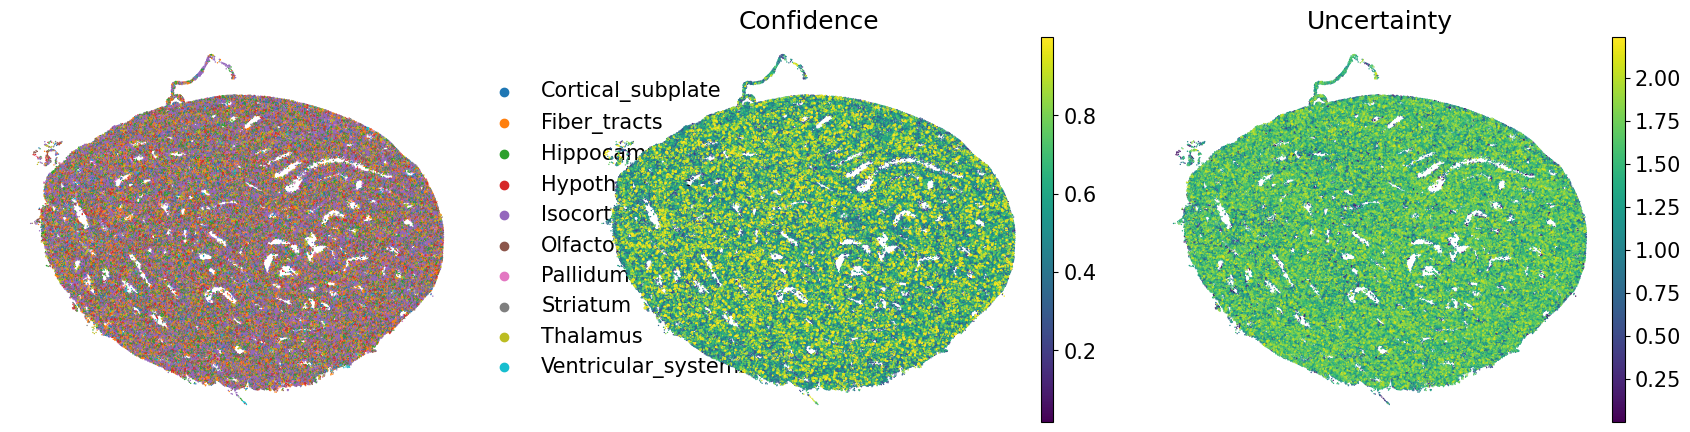

In [20]:
import matplotlib.pyplot as plt
import copy
plt.rcParams['figure.figsize'] = (6,5)
plt.rcParams['font.size'] = 15
sc.pl.embedding(adata_batch2, basis="spatial",s=4,color=['Transfer_label','Confidence','Uncertainty'],title='',frameon=False)

### Predictive labels and Confidence of same tissues

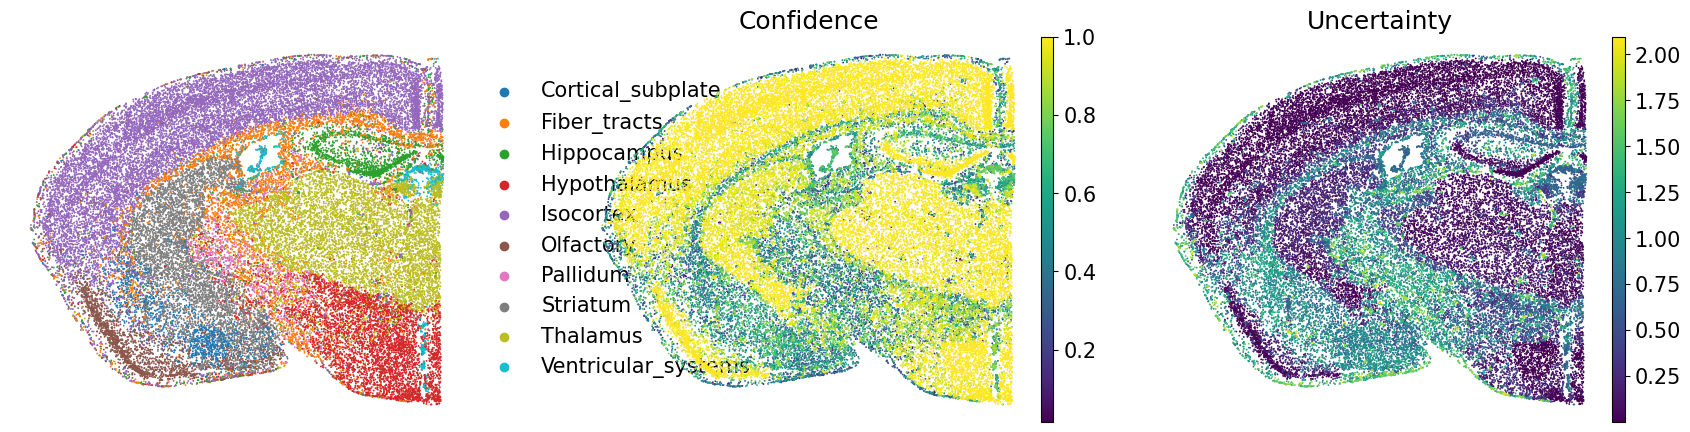

In [21]:
import matplotlib.pyplot as plt
import copy
plt.rcParams['figure.figsize'] = (6,5)
plt.rcParams['font.size'] = 15
sc.pl.embedding(adata_batch3, basis="spatial",s=7,color=['Transfer_label','Confidence','Uncertainty'],title='',frameon=False)

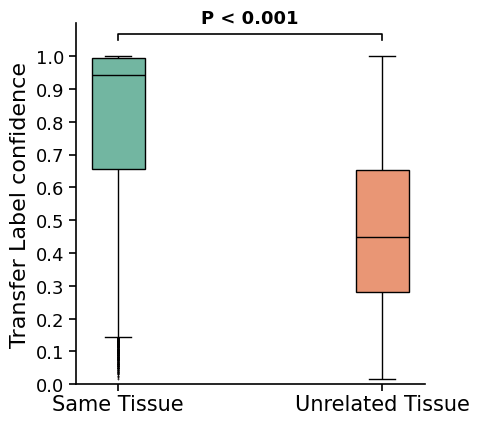

In [22]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

uncert_batch2 = adata_batch2.obs['Confidence'].values
uncert_batch3 = adata_batch3.obs['Confidence'].values

df3 = pd.DataFrame({'Confidence': uncert_batch2, 'Tissue': 'Unrelated Tissue'})
df2 = pd.DataFrame({'Confidence': uncert_batch3, 'Tissue': 'Same Tissue'})
df_plot = pd.concat([df2, df3], ignore_index=True)

method_order = ['Same Tissue', 'Unrelated Tissue']
stat, p_value = mannwhitneyu(uncert_batch3, uncert_batch2, alternative='two-sided')
plt.figure(figsize=(5, 4.5))
fig = plt.gcf()
flierprops = dict(marker='s', markersize=0.1, markerfacecolor='red', markeredgecolor='black') 
ax = sns.boxplot(x='Tissue', y='Confidence', data=df_plot, 
                 palette='Set2', order=method_order, 
                 linecolor='black', linewidth=1, width=0.2, flierprops=flierprops)

y_max = df_plot['Confidence'].max()
y_range = y_max - df_plot['Confidence'].min()

bar_y = y_max + (y_range * 0.05)
bar_height = y_range * 0.02

plt.plot([0, 0, 1, 1], [bar_y, bar_y + bar_height, bar_y + bar_height, bar_y], lw=1.2, c='black')

p_text = f'P < 0.001' if p_value < 0.001 else f'P = {p_value:.3f}'
plt.text(0.5, bar_y + bar_height + (y_range * 0.02), p_text, 
         ha='center', va='bottom', fontsize=13, color='black', fontweight='bold')
# ==========================================================

plt.title('', fontsize=18)
plt.xlabel('', fontsize=12)
plt.ylabel('Transfer Label confidence', fontsize=16) 
ax.tick_params(axis='x', rotation=0, labelsize=15, length=5, width=1.2, pad=2, bottom=True)
ax.tick_params(axis='y', length=5, width=1.2, labelsize=13, left=True)
plt.ylim(0, 1.1) 
plt.yticks(np.arange(0, 1.01, 0.1)) 
for spine in ax.spines.values():
    spine.set_linewidth(1.2)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
fig.savefig('/home/dbj/SpaLP/gittest/SpaLP/general/MERFISH/unrelatedtissues/boxplotConfidence.png', dpi=800, bbox_inches='tight')
plt.show()